## 1. Import data and libs

In [ ]:
%pip install pandas seaborn matplotlib 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
# Reimport necessary libraries after environment reset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data from the provided Excel file
file_path = 'LittleLemon_data.xlsx'

# Read the data into a pandas dataframe
df = pd.read_excel(file_path)

# Display the first few rows of the dataframe to verify the content
df.head()


,Row Number,Order ID,Order Date,Delivery Date,Customer ID,Customer Name,City,Country,Postal Code,Country Code,...,Sales,Quantity,Discount,Delivery Cost,Course Name,Cuisine Name,Starter Name,Desert Name,Drink,Sides
0,1,54-366-6861,2020-06-15,2020-03-26,72-055-7985,Laney Fadden,Daruoyan,China,993-0031,CN,...,187.5,2,20.00,60.51,Greek salad,Greek,Olives,Greek yoghurt,Athens White wine,Tapas
1,2,63-761-3686,2020-08-25,2020-07-17,65-353-0657,Giacopo Bramich,Ongjin,North Korea,216282,KP,...,352.5,1,15.00,96.75,Bean soup,Italian,Flatbread,Ice cream,Corfu Red Wine,Potato salad
2,3,65-351-6434,2021-08-17,2020-04-24,90-876-6799,Lia Bonar,Quince Mil,Peru,663246,PE,...,112.5,3,10.52,36.37,Pizza,Italian,Minestrone,Cheesecake,Italian Coffee,Bruschetta
3,4,36-917-2834,2021-08-14,2020-04-13,73-873-4827,Merrill Baudon,Susaki,Japan,987-0352,JP,...,330.0,3,11.23,5.49,Carbonara,Turkish,Tomato bread,Affogato,Roma Red wine,Focaccia
4,5,86-114-9232,2020-12-20,2021-02-02,80-927-5246,Tasia Fautly,Tobruk,Libya,351 01,LY,...,480.0,2,51.05,63.64,Kabasa,Greek,Falafel,Turkish yoghurt,Ankara White Wine,Meatballs


## 2. Total Sales

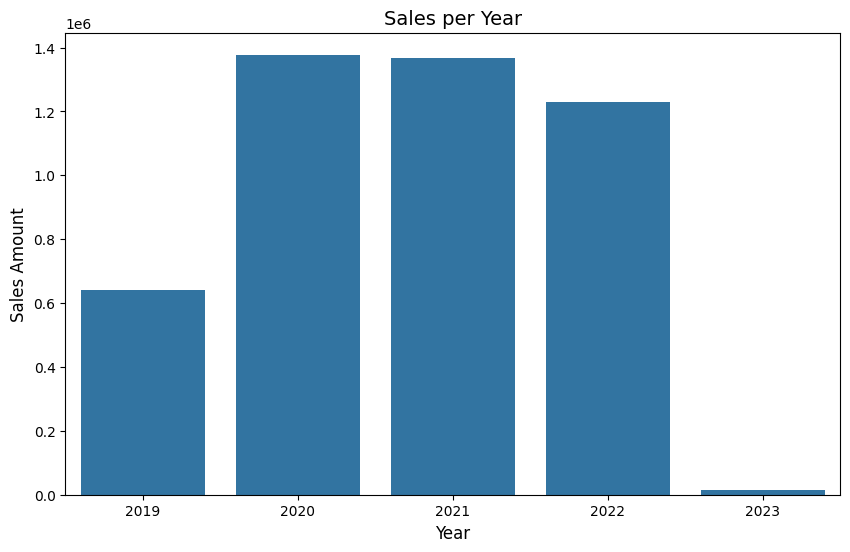

In [5]:
# Convert 'Order Date' to datetime to extract the year
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Extract year from 'Order Date'
df['Order Year'] = df['Order Date'].dt.year

# Group data by year and calculate total sales per year
sales_per_year = df.groupby('Order Year')['Sales'].sum().reset_index()

# Plot the sales per year
plt.figure(figsize=(10, 6))
sns.barplot(x='Order Year', y='Sales', data=sales_per_year)
plt.title('Sales per Year', fontsize=14)
plt.ylabel('Sales Amount', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.show()


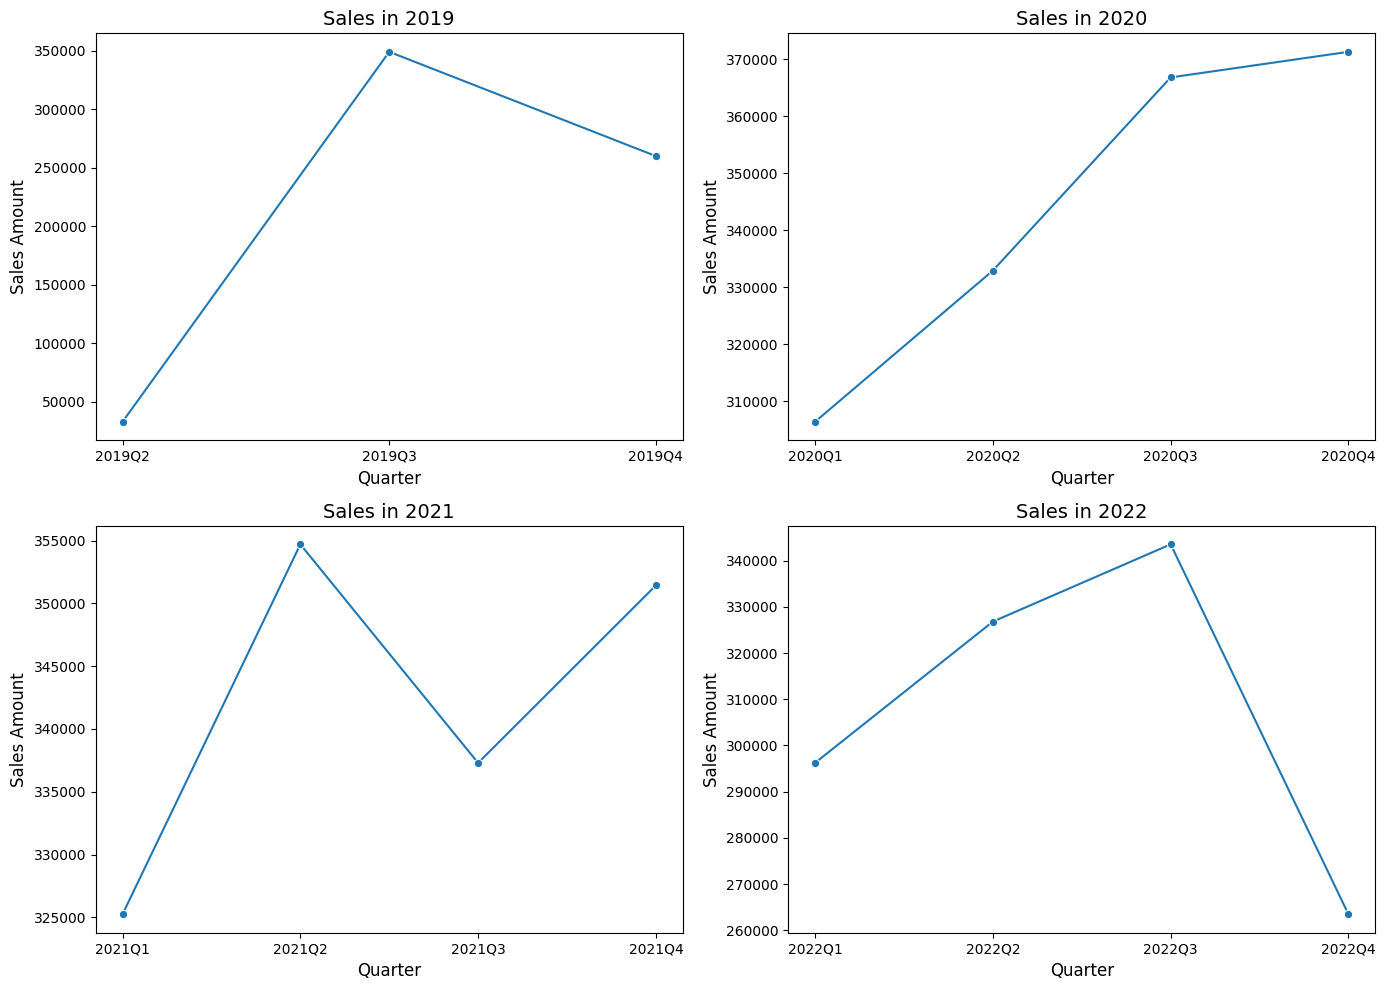

In [10]:
# Ensure that the 'Sales' column is numeric and 'Quarter' is a period (string) for correct plotting
# Convert 'Order Date' to datetime to extract year and quarter
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Extract Year and Quarter from the 'Order Date'
df['Year'] = df['Order Date'].dt.year
df['Quarter'] = df['Order Date'].dt.to_period('Q')

# Ensure 'Quarter' is of type string for plotting
df['Quarter'] = df['Quarter'].astype(str)

# Group by Year and Quarter and calculate total sales for each combination
sales_by_quarter = df.groupby(['Year', 'Quarter'])['Sales'].sum().reset_index()

# Plot line charts for each year (2019, 2020, 2021, 2022) showing sales per quarter
plt.figure(figsize=(14, 10))

# Loop through each year and create a line chart
years = [2019, 2020, 2021, 2022]
for idx, year in enumerate(years, 1):
    plt.subplot(2, 2, idx)
    year_data = sales_by_quarter[sales_by_quarter['Year'] == year]
    sns.lineplot(x='Quarter', y='Sales', data=year_data, marker='o')
    plt.title(f'Sales in {year}', fontsize=14)
    plt.ylabel('Sales Amount', fontsize=12)
    plt.xlabel('Quarter', fontsize=12)

plt.tight_layout()
plt.show()


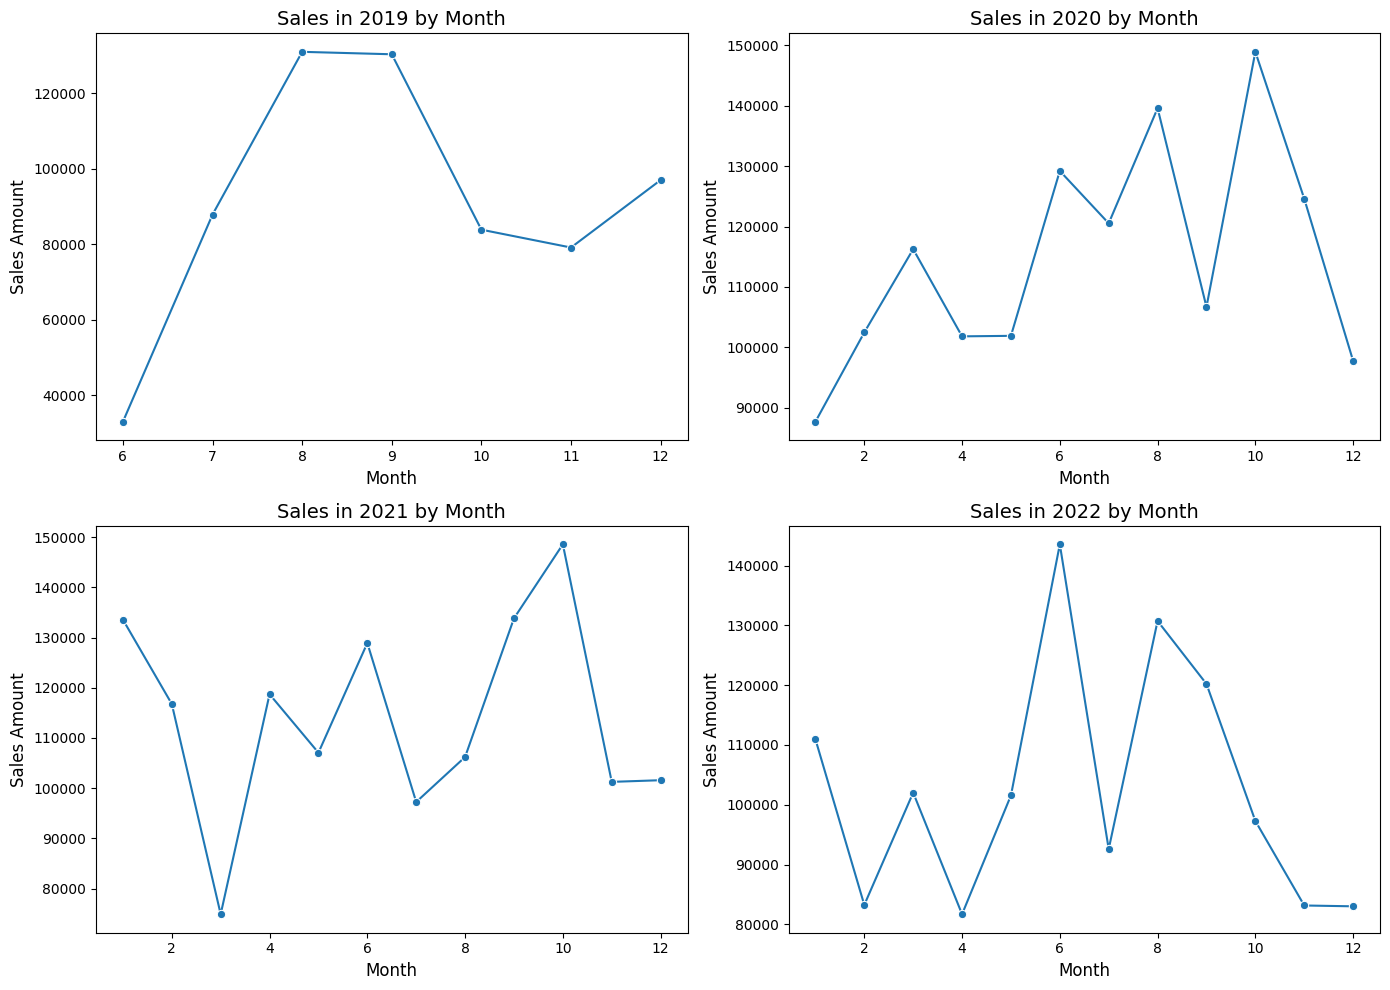

In [11]:
# Extract month from 'Order Date' and group by Year and Month
df['Month'] = df['Order Date'].dt.month

# Group by Year and Month and calculate total sales for each combination
sales_by_month = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

# Plot line charts for each year (2019, 2020, 2021, 2022) showing sales per month
plt.figure(figsize=(14, 10))

# Loop through each year and create a line chart
for idx, year in enumerate(years, 1):
    plt.subplot(2, 2, idx)
    year_data = sales_by_month[sales_by_month['Year'] == year]
    sns.lineplot(x='Month', y='Sales', data=year_data, marker='o')
    plt.title(f'Sales in {year} by Month', fontsize=14)
    plt.ylabel('Sales Amount', fontsize=12)
    plt.xlabel('Month', fontsize=12)

plt.tight_layout()
plt.show()


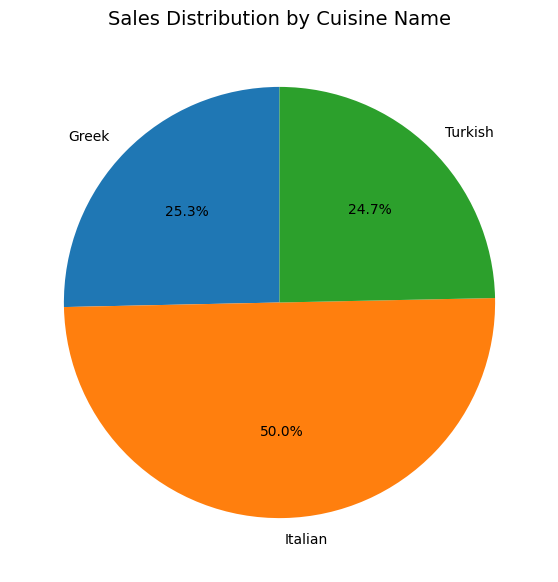

In [6]:
# Group data by 'Cuisine Name' and calculate total sales per cuisine
sales_by_cuisine = df.groupby('Cuisine Name')['Sales'].sum().reset_index()

# Plot the sales distribution by cuisine name as a pie chart
plt.figure(figsize=(7, 7))
plt.pie(sales_by_cuisine['Sales'], labels=sales_by_cuisine['Cuisine Name'], autopct='%1.1f%%', startangle=90)
plt.title('Sales Distribution by Cuisine Name', fontsize=14)
plt.show()


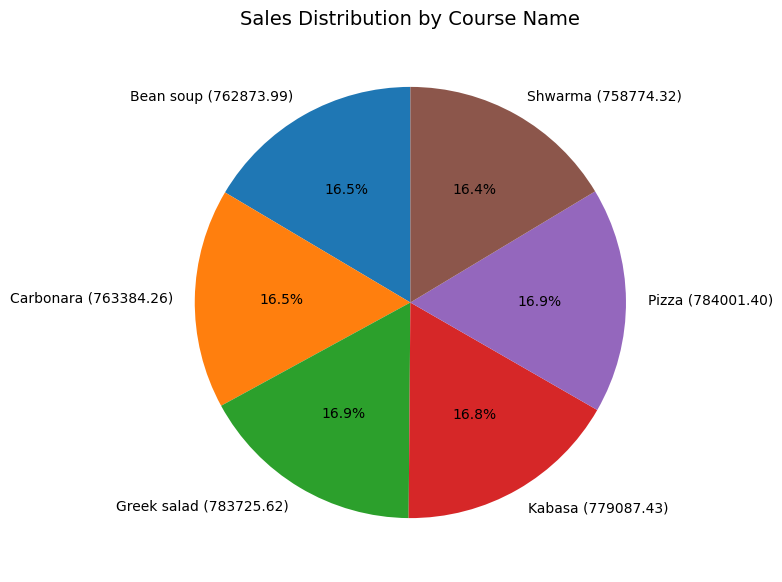

In [12]:
# Group data by 'Course Name' and calculate total sales per course
sales_by_course = df.groupby('Course Name')['Sales'].sum().reset_index()

# Add a label with total sales for each course
labels = [f"{course} ({sales:.2f})" for course, sales in zip(sales_by_course['Course Name'], sales_by_course['Sales'])]

# Plot the sales distribution by course name as a pie chart with sales labels
plt.figure(figsize=(7, 7))
plt.pie(sales_by_course['Sales'], labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Sales Distribution by Course Name', fontsize=14)
plt.show()


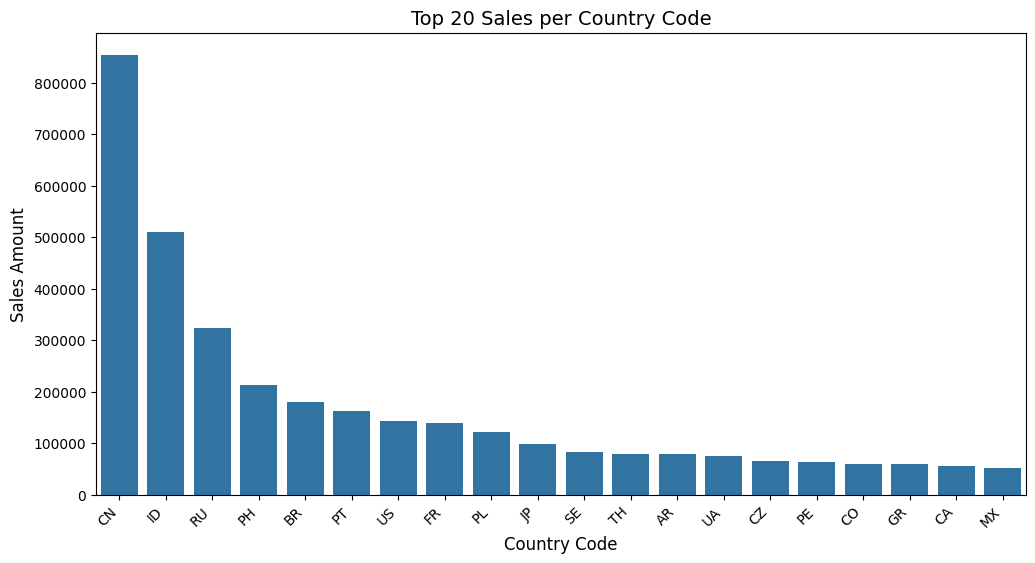

In [8]:
# Filter the top 20 Country Codes with the highest sales
top_20_sales_by_country = sales_by_country_code_sorted.head(20)

# Plot the sales distribution for the top 20 country codes as a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x='Country Code', y='Sales', data=top_20_sales_by_country)
plt.title('Top 20 Sales per Country Code', fontsize=14)
plt.ylabel('Sales Amount', fontsize=12)
plt.xlabel('Country Code', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()



## 3. Total Cost

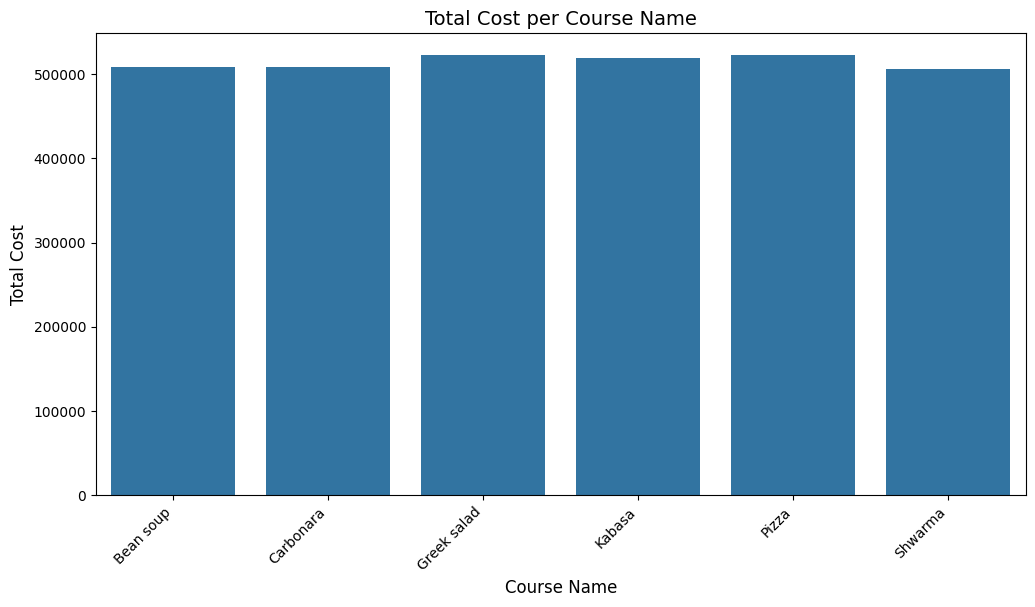

In [13]:
# Remove leading and trailing spaces in column names
df.columns = df.columns.str.strip()

# Group by 'Course Name' and calculate total cost for each course
cost_by_course = df.groupby('Course Name')['Cost'].sum().reset_index()

# Plot the cost distribution for each course category (Starter, Main Course, Dessert)
plt.figure(figsize=(12, 6))
sns.barplot(x='Course Name', y='Cost', data=cost_by_course)
plt.title('Total Cost per Course Name', fontsize=14)
plt.ylabel('Total Cost', fontsize=12)
plt.xlabel('Course Name', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()


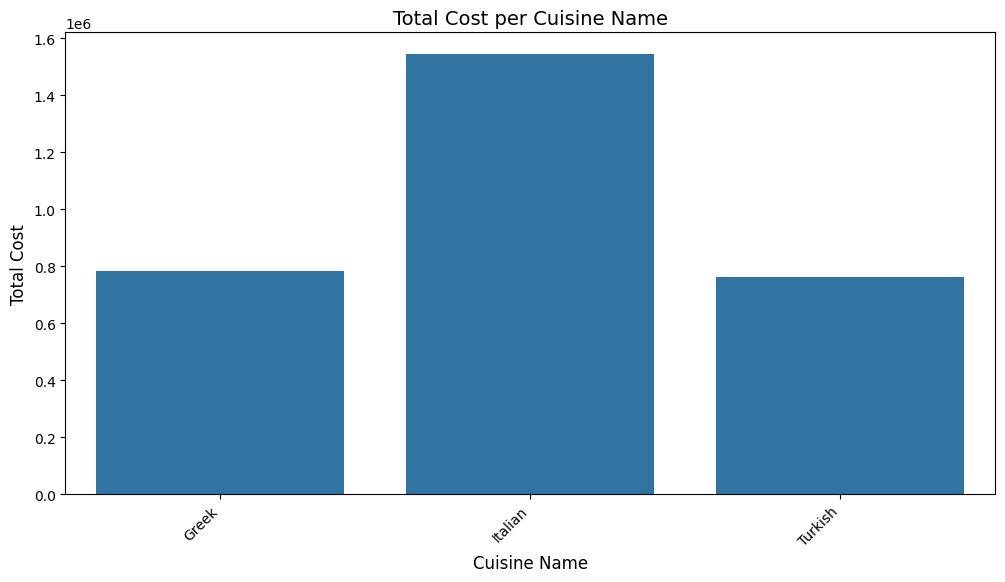

In [14]:
# Group by 'Cuisine Name' and calculate total cost for each cuisine
cost_by_cuisine = df.groupby('Cuisine Name')['Cost'].sum().reset_index()

# Plot the cost distribution for each cuisine category
plt.figure(figsize=(12, 6))
sns.barplot(x='Cuisine Name', y='Cost', data=cost_by_cuisine)
plt.title('Total Cost per Cuisine Name', fontsize=14)
plt.ylabel('Total Cost', fontsize=12)
plt.xlabel('Cuisine Name', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()


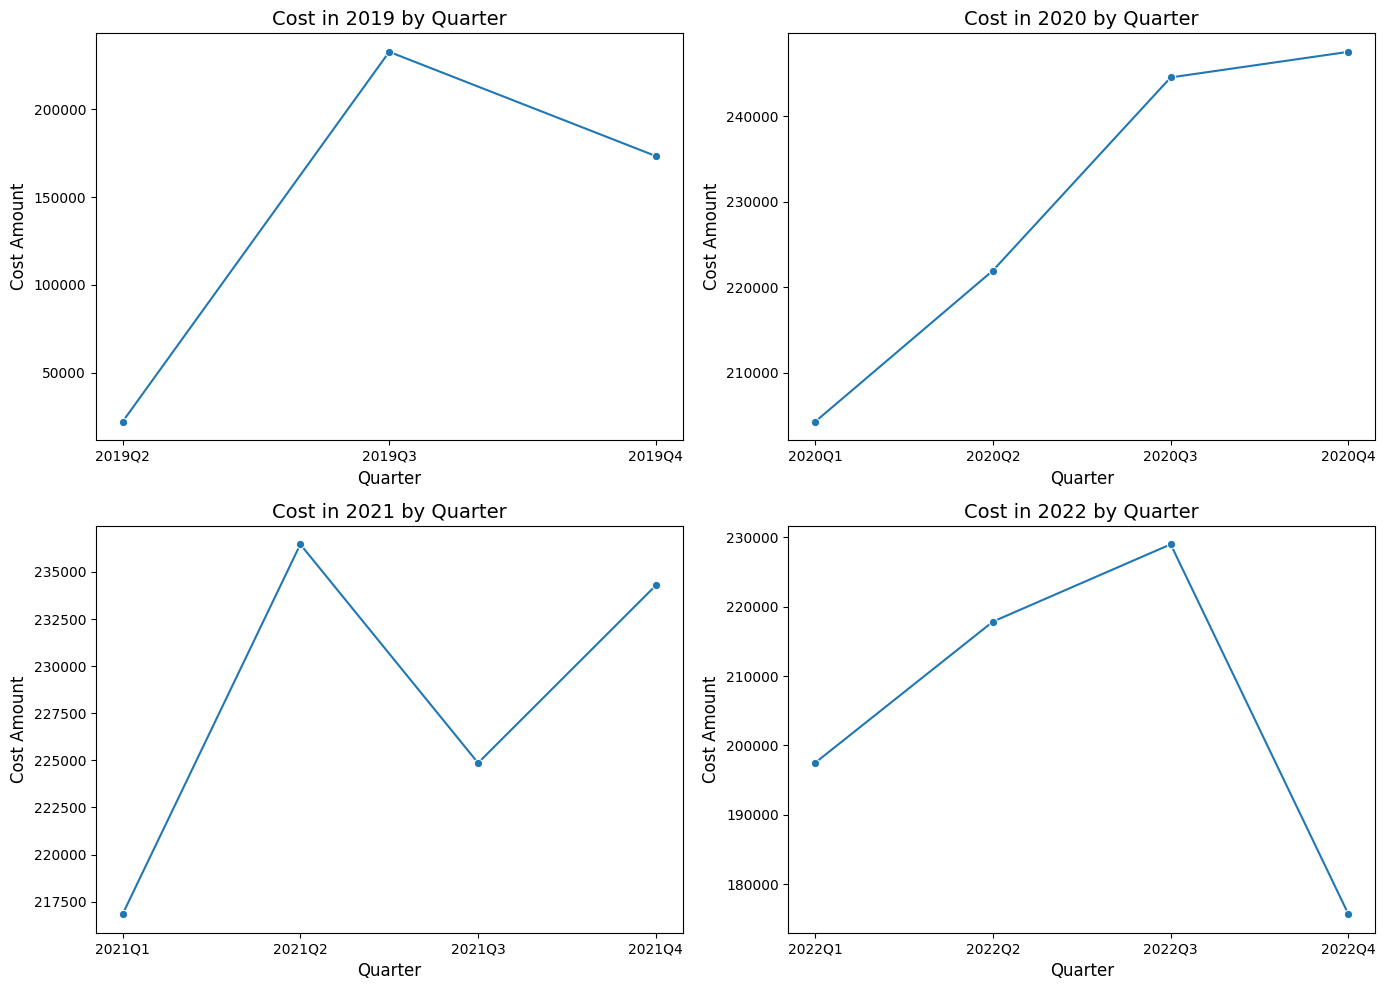

In [15]:
# Ensure that the 'Quarter' column is a string (Q1, Q2, Q3, Q4) format for proper plotting
df['Quarter'] = df['Quarter'].astype(str)

# Group by Year and Quarter, and calculate total cost for each combination
cost_by_quarter_time = df.groupby(['Year', 'Quarter'])['Cost'].sum().reset_index()

# Plot line charts for each year (2019, 2020, 2021, 2022) showing cost per quarter
plt.figure(figsize=(14, 10))

# Loop through each year and create a line chart
for idx, year in enumerate(years, 1):
    plt.subplot(2, 2, idx)
    year_data = cost_by_quarter_time[cost_by_quarter_time['Year'] == year]
    sns.lineplot(x='Quarter', y='Cost', data=year_data, marker='o')
    plt.title(f'Cost in {year} by Quarter', fontsize=14)
    plt.ylabel('Cost Amount', fontsize=12)
    plt.xlabel('Quarter', fontsize=12)

plt.tight_layout()
plt.show()


## 4. Gross Profit

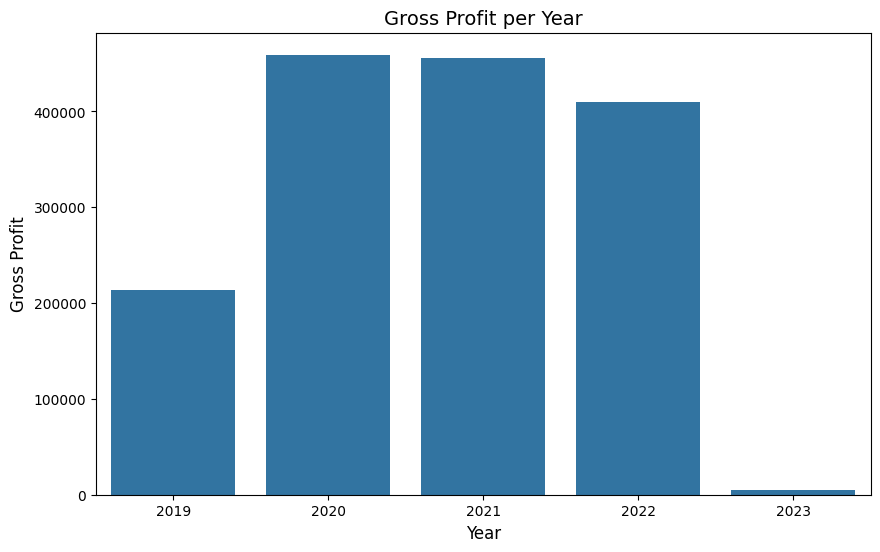

In [16]:
# Group data by Year and calculate total sales and total cost for each year
sales_by_year = df.groupby('Year')['Sales'].sum().reset_index()
cost_by_year = df.groupby('Year')['Cost'].sum().reset_index()

# Merge the sales and cost data on 'Year' to calculate gross profit
gross_profit_by_year = pd.merge(sales_by_year, cost_by_year, on='Year', how='left')

# Calculate Gross Profit (Sales - Cost)
gross_profit_by_year['Gross Profit'] = gross_profit_by_year['Sales'] - gross_profit_by_year['Cost']

# Plot the Gross Profit per Year
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Gross Profit', data=gross_profit_by_year)
plt.title('Gross Profit per Year', fontsize=14)
plt.ylabel('Gross Profit', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.show()


## 5. Total Quantity

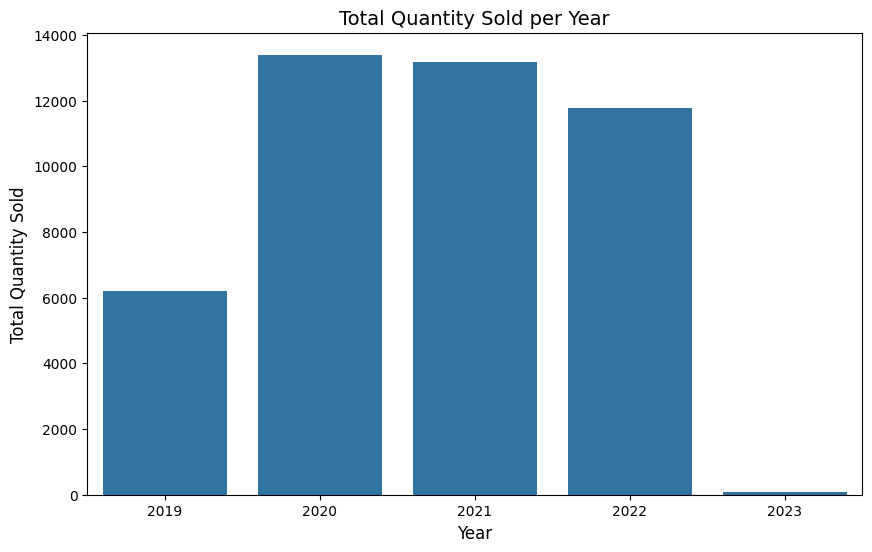

In [17]:
# Group by Year and calculate total quantity sold for each year
quantity_by_year = df.groupby('Year')['Quantity'].sum().reset_index()

# Plot the Total Quantity Sold per Year
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Quantity', data=quantity_by_year)
plt.title('Total Quantity Sold per Year', fontsize=14)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.show()


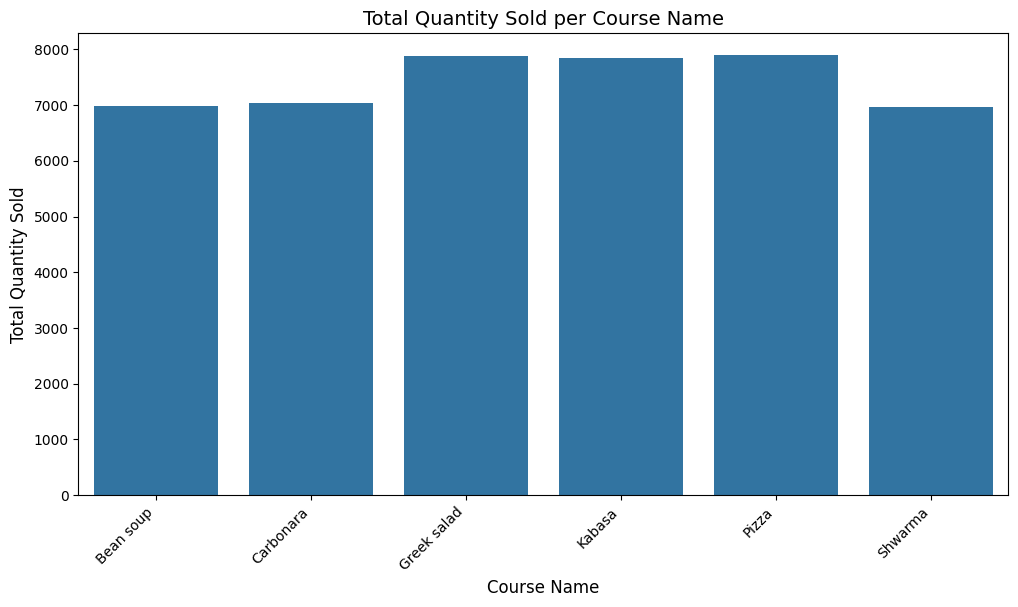

In [18]:
# Group by 'Course Name' and calculate total quantity sold for each course
quantity_by_course = df.groupby('Course Name')['Quantity'].sum().reset_index()

# Plot the Total Quantity Sold per Course Name
plt.figure(figsize=(12, 6))
sns.barplot(x='Course Name', y='Quantity', data=quantity_by_course)
plt.title('Total Quantity Sold per Course Name', fontsize=14)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.xlabel('Course Name', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()


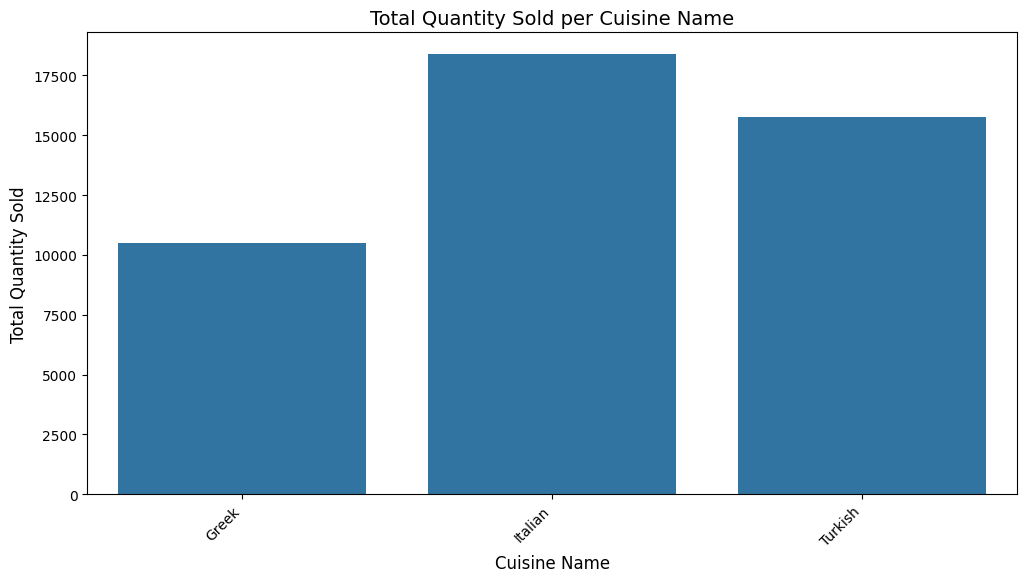

In [19]:
# Group by 'Cuisine Name' and calculate total quantity sold for each cuisine
quantity_by_cuisine = df.groupby('Cuisine Name')['Quantity'].sum().reset_index()

# Plot the Total Quantity Sold per Cuisine Name
plt.figure(figsize=(12, 6))
sns.barplot(x='Cuisine Name', y='Quantity', data=quantity_by_cuisine)
plt.title('Total Quantity Sold per Cuisine Name', fontsize=14)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.xlabel('Cuisine Name', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()


## 6. Average Delivery Time

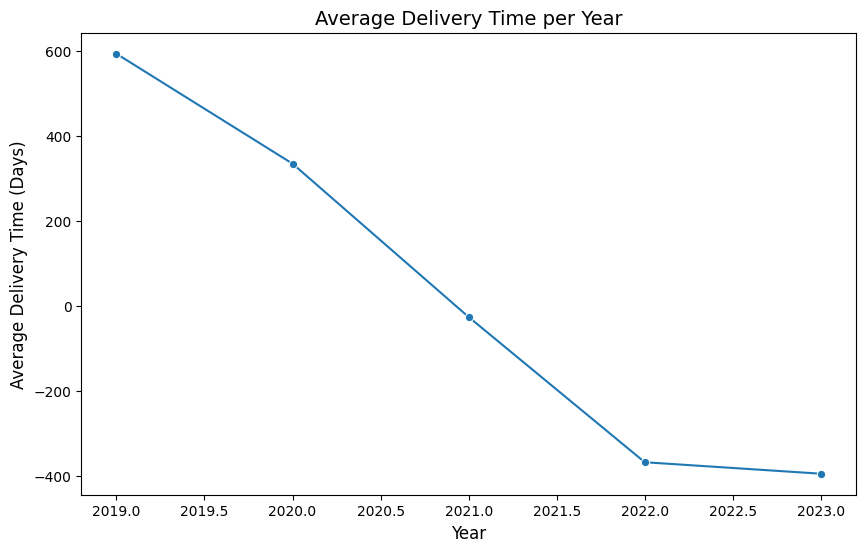

In [20]:
# Convert 'Order Date' and 'Delivery Date' to datetime to calculate the difference
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Delivery Date'] = pd.to_datetime(df['Delivery Date'], errors='coerce')

# Calculate the delivery time for each order (in days)
df['Delivery Time (Days)'] = (df['Delivery Date'] - df['Order Date']).dt.days

# Group by 'Year' and calculate the average delivery time per year
avg_delivery_time_by_year = df.groupby('Year')['Delivery Time (Days)'].mean().reset_index()

# Plot the Average Delivery Time per Year
plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Delivery Time (Days)', data=avg_delivery_time_by_year, marker='o')
plt.title('Average Delivery Time per Year', fontsize=14)
plt.ylabel('Average Delivery Time (Days)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.show()
